In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data_frames/games_march2025_cleaned.csv")

In [4]:
df.head(3)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366


In [5]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [6]:
# Check for missing values
df.isnull().sum()

appid                           0
name                            0
release_date                    0
required_age                    0
price                           0
dlc_count                       0
detailed_description          197
about_the_game                220
short_description             120
reviews                     79217
header_image                    0
website                     48504
support_url                 45508
support_email               10820
windows                         0
mac                             0
linux                           0
metacritic_score                0
metacritic_url              86071
achievements                    0
recommendations                 0
notes                       72975
supported_languages             0
full_audio_languages            0
packages                        0
developers                      0
publishers                      0
categories                      0
genres                          0
screenshots   

In [7]:
# Convert release_date to datetime format
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Fill missing values in reviews with an empty string
df['reviews'] = df['reviews'].fillna('')

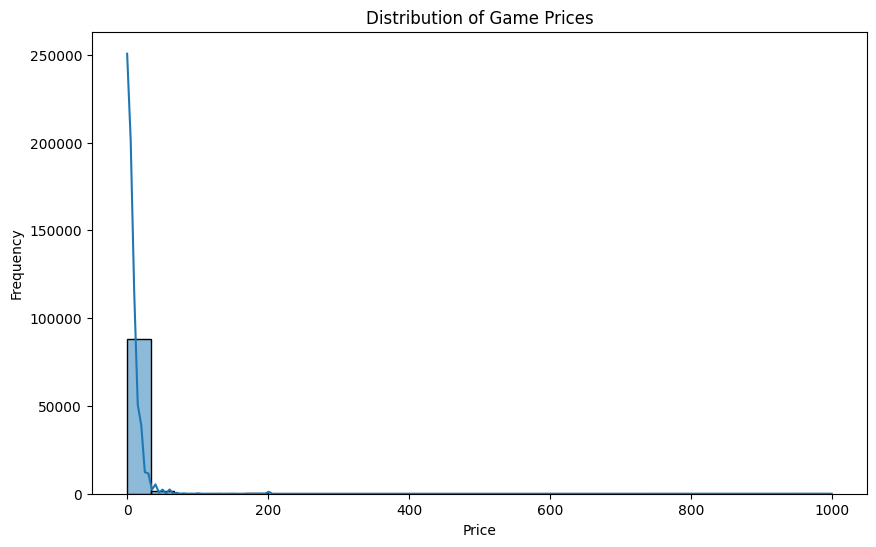

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lets see Distribution of Game Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Game Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

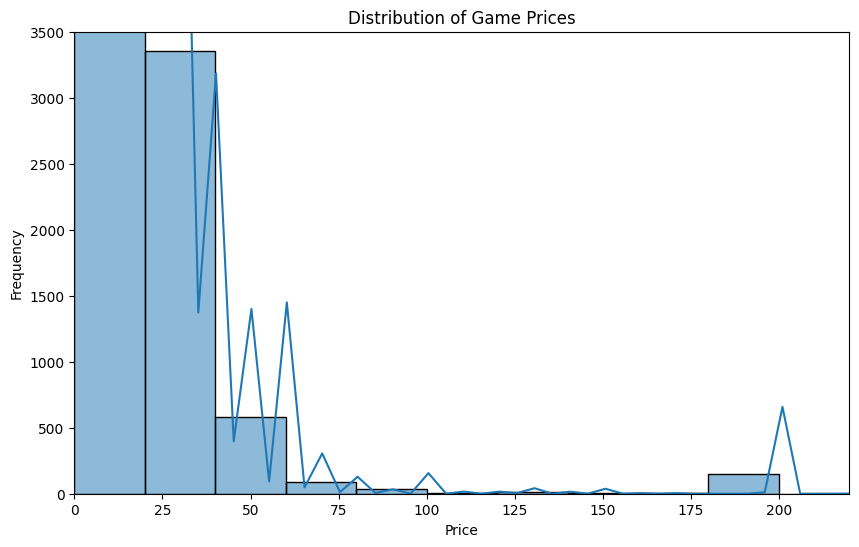

In [9]:
# Lets zoom it
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.ylim(0,3500)
plt.xlim(0,220)
plt.title('Distribution of Game Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

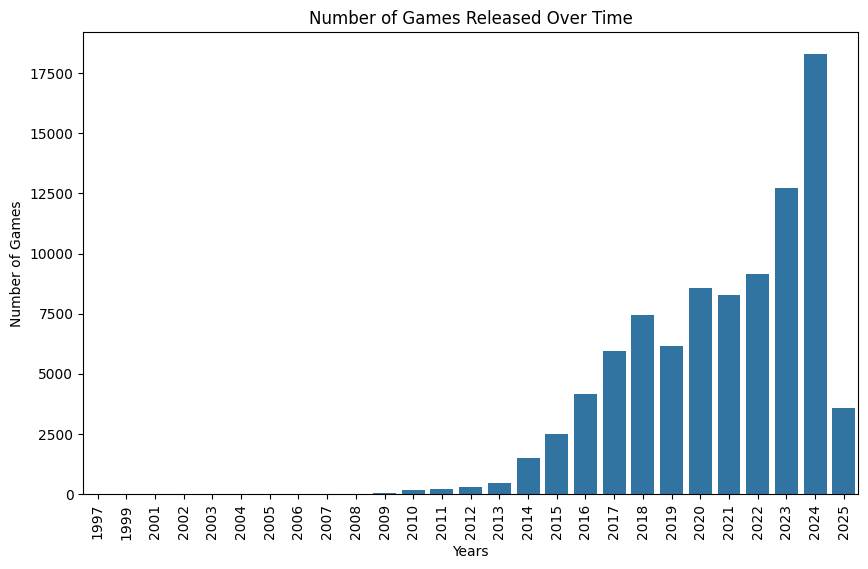

In [10]:
# Number of games released over time
df_plot_year = df.groupby(df['release_date'].dt.year)['name'].count().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=df_plot_year.index, y=df_plot_year.values)
plt.title('Number of Games Released Over Time')
plt.xlabel('Years')
plt.ylabel('Number of Games')
plt.xticks(rotation=90)
plt.show()

developers
[]                                221
['EroticGamesClub']               196
['Choice of Games']               158
['Laush Dmitriy Sergeevich']      138
['Boogygames Studios']            133
['Creobit']                       116
['Hosted Games']                  106
['Gamesforgames']                 105
['KOEI TECMO GAMES CO., LTD.']    105
['Sokpop Collective']              95
Name: count, dtype: int64


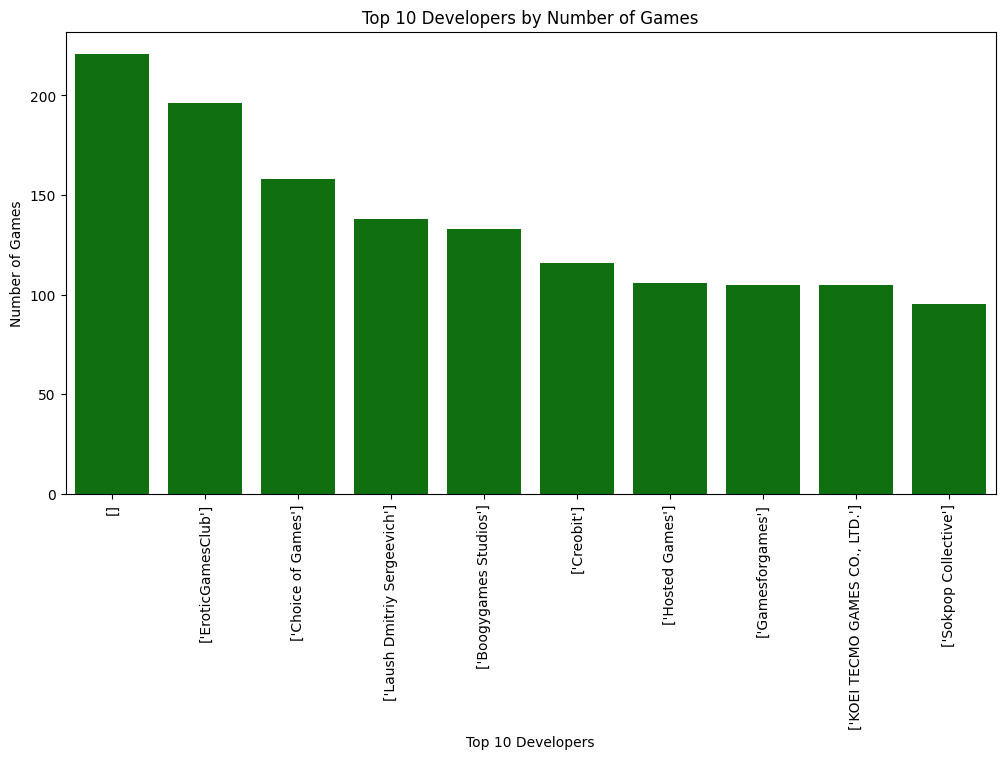

In [ ]:
# Top 10 developers by number of games
top10_developers = df['developers'].value_counts().head(10)
print(top10_developers)
plt.figure(figsize=(12,6))
sns.barplot(x=top10_developers.index, y=top10_developers.values, color='green')
plt.title('Top 10 Developers by Number of Games')
plt.xlabel('Developers')
plt.ylabel('Number of Games')
plt.xticks(rotation=90)
plt.show()

                                            name  metacritic_score
171                Disco Elysium - The Final Cut                97
3                      Grand Theft Auto V Legacy                96
16                               Baldur's Gate 3                96
12                                    ELDEN RING                94
724    Divinity: Original Sin - Enhanced Edition                94
14851               Mass Effect 2 (2010) Edition                94
89                   The Elder Scrolls V: Skyrim                94
3074                                 Cobalt Core                94
160                            BioShock Infinite                94
57                                         Hades                93


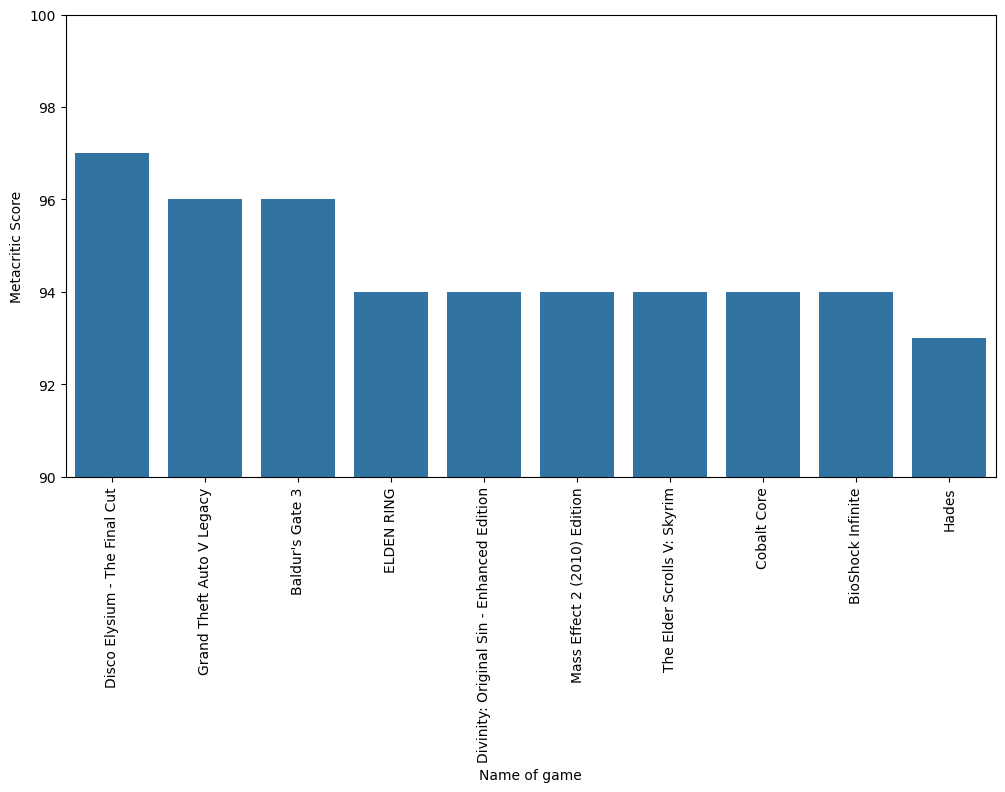

In [12]:
# Top 10 games rating my metacritic score
top10_by_metacritic_score = df[['name', 'metacritic_score']].sort_values(['metacritic_score'],ascending=[False]).head(10)
print(top10_by_metacritic_score)
plt.figure(figsize=(12,6))
sns.barplot(x=top10_by_metacritic_score['name'], y=top10_by_metacritic_score['metacritic_score'])
plt.ylim(90,100)
plt.xlabel('Name of game')
plt.ylabel('Metacritic Score')
plt.xticks(rotation=90)
plt.show()

new_genres
Video Production         21.144772
Audio Production         20.495897
Web Publishing           19.855960
Animation & Modeling     18.894467
Design & Illustration    18.112065
Game Development         17.707852
Photo Editing            17.430537
Software Training        16.219792
Education                14.573410
Accounting               12.785833
Utilities                11.124942
Sports                   10.121610
Racing                    9.402178
Simulation                9.116004
RPG                       9.003451
Name: price, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_6204\2459318426.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_avg_price.index, y=df_avg_price.values, palette='Blues')


<function matplotlib.pyplot.show(close=None, block=None)>

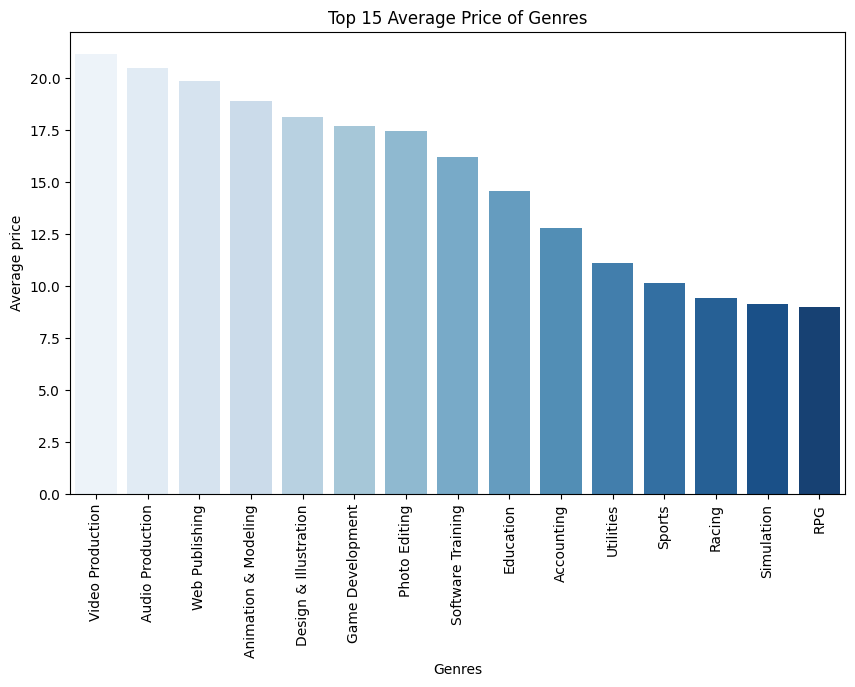

In [85]:
# Top 15 average price of genres
import ast
# Genres are written as "[]", let's turn them into a list and then expand it
def parse_list(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []
    
df_genres = df.assign(new_genres=df['genres'])
df_genres['new_genres'] = df_genres['new_genres'].apply(parse_list)
df_exploded = df_genres.explode('new_genres')
df_avg_price = df_exploded.groupby(['new_genres'])['price'].mean().sort_values(ascending=False).head(15)

print(df_avg_price)

plt.figure(figsize=(10,6))
sns.barplot(x=df_avg_price.index, y=df_avg_price.values, palette='Blues')
plt.title('Top 15 Average Price of Genres')
plt.xticks(rotation=90)
plt.xlabel('Genres')
plt.ylabel('Average price')
plt.show

                                  name  recommendations
0                     Counter-Strike 2          4401572
3            Grand Theft Auto V Legacy          1803063
1                  PUBG: BATTLEGROUNDS          1732007
4      Tom Clancy's Rainbow Six® Siege          1165929
6                             Terraria          1098792
7                                 Rust           992825
8                          Garry's Mod           984713
10                  Black Myth: Wukong           825294
56729                 Wallpaper Engine           809225
11            The Witcher 3: Wild Hunt           761658


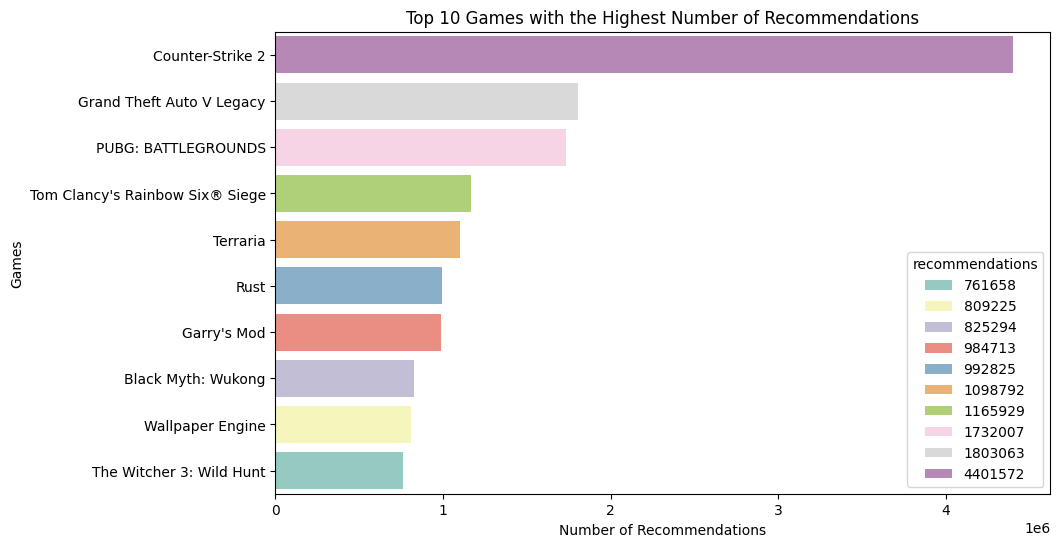

In [69]:
# Top 10 Games with the Highest Number of Recommendations
top10_recommendations = df[['name', 'recommendations']].sort_values('recommendations', ascending=False).head(10)
print(top10_recommendations)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_recommendations['recommendations'], y=top10_recommendations['name'],hue=top10_recommendations['recommendations'], palette='Set3')
plt.title('Top 10 Games with the Highest Number of Recommendations')
plt.xlabel('Number of Recommendations')
plt.ylabel('Games')
plt.show()


                              name  peak_ccu
0                 Counter-Strike 2   1212356
182           Monster Hunter Wilds    703236
1              PUBG: BATTLEGROUNDS    616738
2                           Dota 2    555977
924                  Split Fiction    201694
7                             Rust    200902
9                    Apex Legends™    151844
825    Grand Theft Auto V Enhanced    127949
818                       R.E.P.O.    127336
56729             Wallpaper Engine    120461


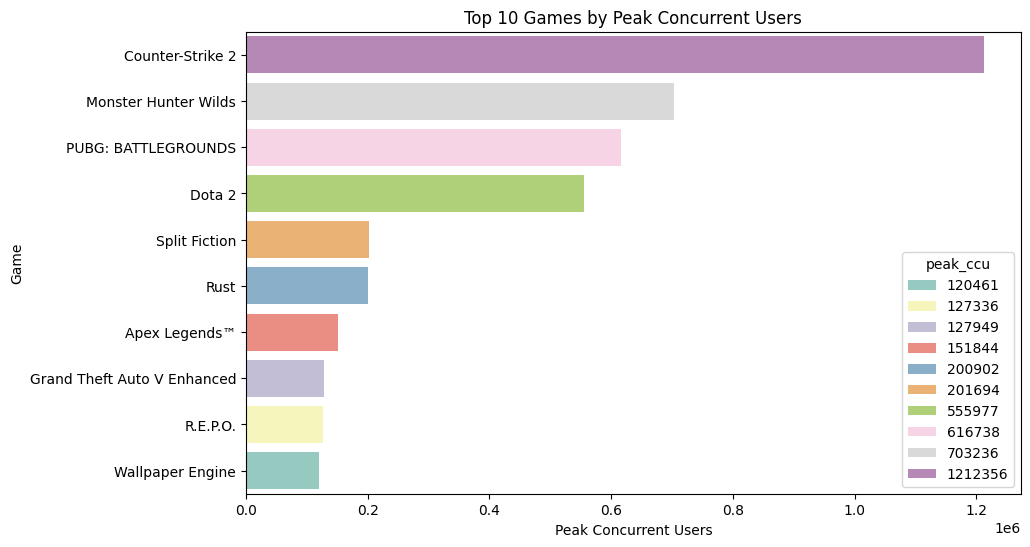

In [73]:
# Top 10 Games by Peak Concurrent Users
top10_peak_ccu = df[['name', 'peak_ccu']].sort_values('peak_ccu', ascending=False).head(10)
print(top10_peak_ccu)
plt.figure(figsize=(10,6))
sns.barplot(x=top10_peak_ccu['peak_ccu'], y=top10_peak_ccu['name'], hue=top10_peak_ccu['peak_ccu'], palette='Set3')
plt.title('Top 10 Games by Peak Concurrent Users')
plt.xlabel('Peak Concurrent Users')
plt.ylabel('Game')
plt.show()

windows    89588
mac        17438
linux      12627
dtype: int64


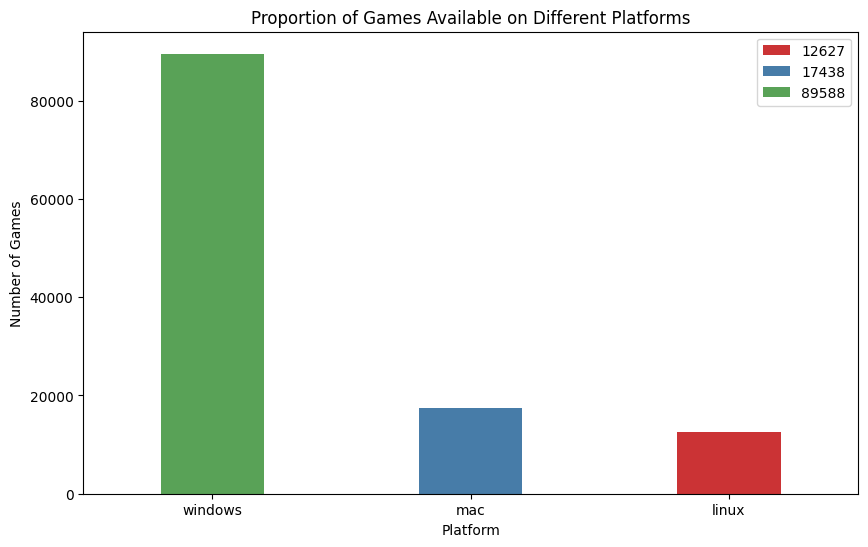

In [125]:
# Proportion of Games Available on Different Platforms
platform_counts = df[['windows','mac','linux']].sum()
print(platform_counts)

plt.figure(figsize=(10,6), edgecolor='black')
sns.barplot(x=platform_counts.index, y=platform_counts.values, hue=platform_counts.values, palette='Set1', width=0.4)
plt.title('Proportion of Games Available on Different Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.show()